## Business Problem

Customer churn is a major challenge for telecom companies because they lose customers directly reducing revenue.

The goal of this project is to:

1. Predict which customers are likely to churn

2. Identify key factors driving churn

3. Provide actionable recommendations to reduce customer loss

In [379]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

## Loading and Inspecting the Data

In [380]:
# loading syrian telephone data
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [381]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

## Data Cleaning

In [382]:
# checking for null values
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Phone number is just an ID, it has no predictive value, so we drop it

In [383]:
# dropping useless columns
df = df.drop(columns=["phone number"], errors="ignore")


In [384]:
# confirming phone number column is dropped
print(df.columns)

Index(['state', 'account length', 'area code', 'international plan',
       'voice mail plan', 'number vmail messages', 'total day minutes',
       'total day calls', 'total day charge', 'total eve minutes',
       'total eve calls', 'total eve charge', 'total night minutes',
       'total night calls', 'total night charge', 'total intl minutes',
       'total intl calls', 'total intl charge', 'customer service calls',
       'churn'],
      dtype='object')


In [385]:
# converting categorical variables to dummy variables
df["international plan"] = df["international plan"].map({"yes": 1, "no": 0})
df["voice mail plan"] = df["voice mail plan"].map({"yes": 1, "no": 0})
df["churn"] = df["churn"].astype(int)

In [386]:
# one hot encoding for state column
df = pd.get_dummies(df, columns=["state"], drop_first=True)

In [387]:
# checking for any remaining string columns that need encoding
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


## Exploratory Data Analysis (EDA)

#### Target variable:
churn (1 = leave, 0 = stay)

In [388]:
# churn distribution
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True))

0    2850
1     483
Name: churn, dtype: int64
0    0.855086
1    0.144914
Name: churn, dtype: float64


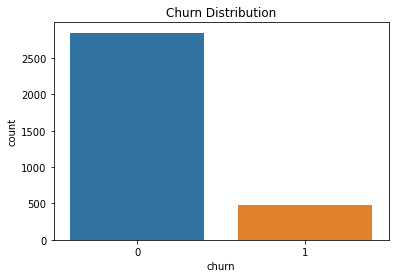

In [389]:
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Customer services calls vs Churn

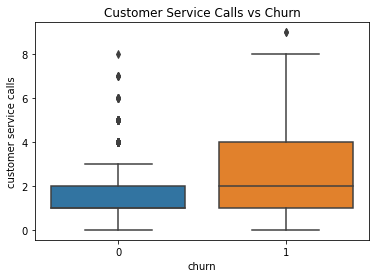

In [390]:
#customer services calls vs churn
sns.boxplot(x="churn", y="customer service calls", data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

#### Finding 1.0
Customers with more customer service calls are more likely to churn

### International plan vs churn

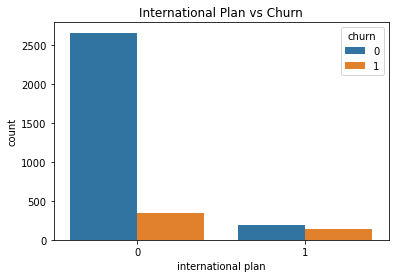

In [391]:
# international plan vs churn
sns.countplot(x="international plan", hue="churn", data=df)
plt.title("International Plan vs Churn")
plt.show()

#### Finding 1.1
Customers with international plans show higher churn rates

### Day minutes vs churn

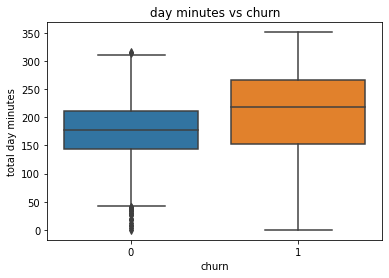

In [392]:
# day minutes vs churn
sns.boxplot(x="churn", y="total day minutes", data=df)
plt.title("day minutes vs churn")
plt.show()

#### Finding 1.3
High daily usage and charges are linked to churn

## Prepare Data for Modeling

In [393]:
# split data into X and y variables
X = df.drop("churn", axis=1)
y = df["churn"]

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Data split
- 80% - training 
- 20% - testing

`stratify = y` keeps churn ratio consistent between train and test sets

In [394]:
# confirming all features are numeric
print(X_train.dtypes)

account length           int64
area code                int64
international plan       int64
voice mail plan          int64
number vmail messages    int64
                         ...  
state_VT                 uint8
state_WA                 uint8
state_WI                 uint8
state_WV                 uint8
state_WY                 uint8
Length: 68, dtype: object


## Build Models

### Random Forest (Best baseline)

In [395]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

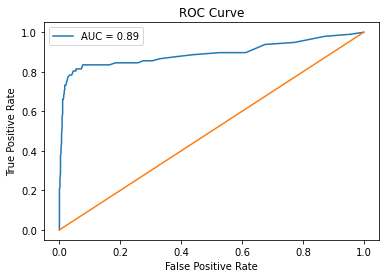

In [396]:
# Get probabilities (NOT predictions)
y_probs = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute AUC
auc_score = roc_auc_score(y_test, y_probs)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1])  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

#### ROC Curve and AUC Analysis

The ROC curve was used to evaluate the model’s ability to distinguish between churners and non-churners.

The model achieved an AUC score of ~0.89, indicating:

- Strong ability to correctly classify customers

- Good separation between churn and non-churn classes

- The curve shows that the model performs significantly better than random guessing.

### Logistic Regression

In [397]:
# logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\SHIRU\anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## Evaluate Models

In [398]:
# evaluating logistic regression and random forest models
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

print("LOGISTIC REGRESSION")
evaluate(model, X_test, y_test)

print("\nRANDOM FOREST")
evaluate(rf, X_test, y_test)


LOGISTIC REGRESSION
Confusion Matrix:
[[551  19]
 [ 78  19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       570
           1       0.50      0.20      0.28        97

    accuracy                           0.85       667
   macro avg       0.69      0.58      0.60       667
weighted avg       0.82      0.85      0.83       667


RANDOM FOREST
Confusion Matrix:
[[564   6]
 [ 39  58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       570
           1       0.91      0.60      0.72        97

    accuracy                           0.93       667
   macro avg       0.92      0.79      0.84       667
weighted avg       0.93      0.93      0.93       667



#### Key Metric:

Recall for churn (class = 1), because missing a churner means losing a customer implying a high business cost 

## Key Insight

In [399]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(5)

print(top_features)

total day minutes         0.134817
total day charge          0.128960
customer service calls    0.115721
international plan        0.065752
total eve charge          0.053032
dtype: float64


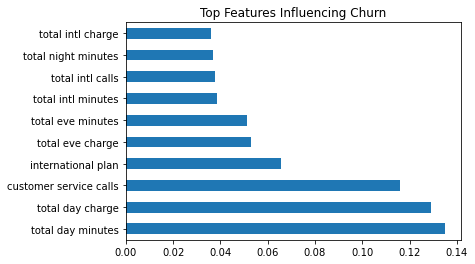

In [400]:
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top Features Influencing Churn")
plt.show()

### Interpreting Results

Key Findings:

1. Customers with high daily usage/charges are at risk

2. Customers with many customer service calls are highly likely to churn

3. Customers with international plans churn more

### Business Recommendations

- Flag high-risk customers early

- Reach out before they leave

- Faster issue resolution

- Reduce repeated complaints

- Offer discounts to heavy users

- Target users with many complaints

## Improving Model

### Handle class imbalance

In [401]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Improve recall

In [402]:
y_probs = rf.predict_proba(X_test)[:, 1]

# Lower threshold
y_pred_custom = (y_probs > 0.3).astype(int)

## conclusion
The model successfully identifies customers at risk of churn.
By acting on these insights, SyriaTel can reduce churn and improve customer retention.
